# 🎓 Aula 01 — O que é IA — História, Timeline e Estado da Arte 2026

**Disciplina:** Prompt Engineering and Artificial Intelligence
**Instituição:** FIAP — Ciência da Computação · 2026
**Professor:** Jorge Luiz Gomes
**Módulo 1 — Fundamentos de IA**

---

## 📋 Objetivo desta aula

Compreender o conceito de Inteligência Artificial, seus marcos históricos, subáreas e o estado da arte em 2026. Ao final, você fará sua primeira chamada a um LLM via Python.

---

## ⚙️ Como usar este notebook

1. Abra no Google Colab (botão "Open in Colab" acima)
2. Execute as células **na ordem**, de cima para baixo
3. Leia os comentários — eles explicam cada passo
4. Faça os exercícios propostos no final

> **💡 Dica:** Use `Shift + Enter` para executar cada célula rapidamente.

---


## 🧠 1. Conceitos Fundamentais


### O que é Inteligência Artificial?

**Definição (Russell & Norvig, 2016):** IA é o estudo de agentes que recebem percepções do ambiente e executam ações. Um agente inteligente toma decisões que maximizam sua medida de desempenho.

**Hierarquia de conceitos:**

```
Inteligência Artificial (IA)
├── Machine Learning (ML) — aprendizado a partir de dados
│   ├── Deep Learning (DL) — redes neurais profundas
│   │   ├── NLP — processamento de linguagem natural
│   │   ├── Computer Vision — visão computacional
│   │   └── IA Generativa — gera conteúdo novo (texto, imagem, código, áudio)
│   │       └── LLMs — modelos de linguagem de grande escala (GPT, Claude, Gemini, LLaMA)
│   ├── Aprendizado Supervisionado
│   ├── Aprendizado Não-Supervisionado
│   └── Aprendizado por Reforço
└── IA Simbólica (sistemas baseados em regras, lógica)
```

**Referência:** Russell & Norvig, Cap. 1–2; Alpaydin, Cap. 1


## 📅 2. Timeline da IA — de 1950 a 2026


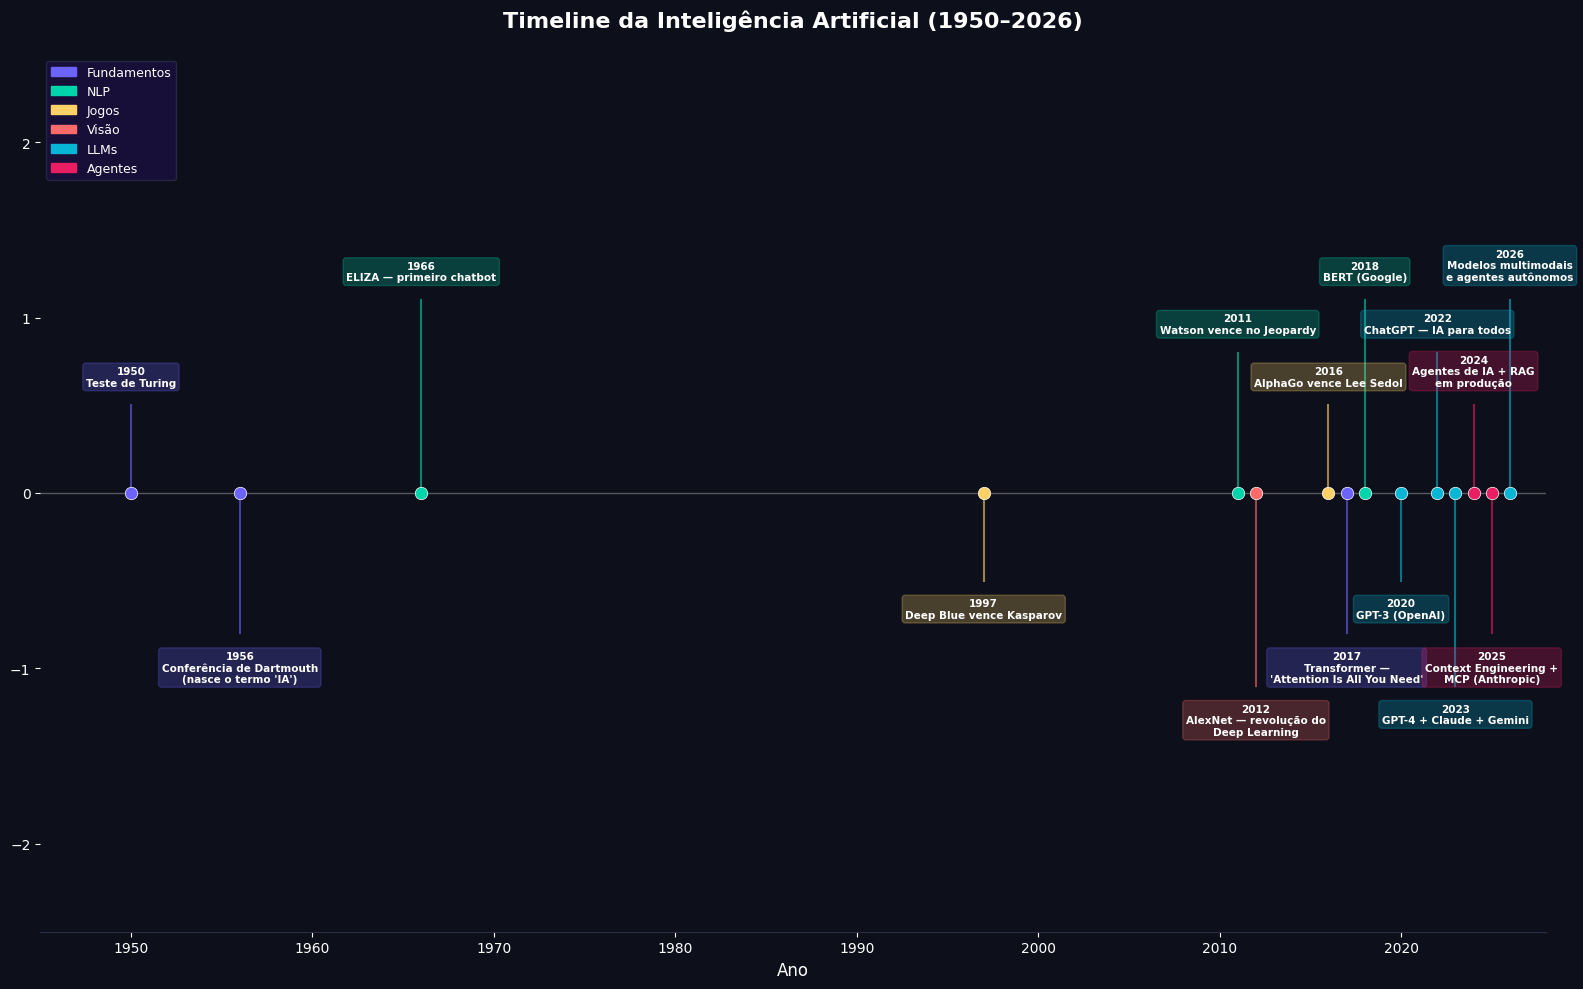


✅ Timeline gerada com sucesso!
📚 Referência: Russell & Norvig, 2016 — Cap. 1


In [ ]:
# ============================================================
# Timeline Interativa da IA — Visualização com matplotlib
# ============================================================
# Este código cria uma visualização da evolução da IA ao longo
# das décadas, desde o Teste de Turing até os modelos de 2026.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dados da timeline: (ano, evento, categoria)
timeline = [
    (1950, "Teste de Turing", "Fundamentos"),
    (1956, "Conferência de Dartmouth\n(nasce o termo 'IA')", "Fundamentos"),
    (1966, "ELIZA — primeiro chatbot", "NLP"),
    (1997, "Deep Blue vence Kasparov", "Jogos"),
    (2011, "Watson vence no Jeopardy", "NLP"),
    (2012, "AlexNet — revolução do\nDeep Learning", "Visão"),
    (2016, "AlphaGo vence Lee Sedol", "Jogos"),
    (2017, "Transformer —\n'Attention Is All You Need'", "Fundamentos"),
    (2018, "BERT (Google)", "NLP"),
    (2020, "GPT-3 (OpenAI)", "LLMs"),
    (2022, "ChatGPT — IA para todos", "LLMs"),
    (2023, "GPT-4 + Claude + Gemini", "LLMs"),
    (2024, "Agentes de IA + RAG\nem produção", "Agentes"),
    (2025, "Context Engineering +\nMCP (Anthropic)", "Agentes"),
    (2026, "Modelos multimodais\ne agentes autônomos", "LLMs"),
]

# Cores por categoria
cores = {
    "Fundamentos": "#6c63ff",
    "NLP": "#00d4aa",
    "Jogos": "#ffd166",
    "Visão": "#ff6b6b",
    "LLMs": "#06b6d4",
    "Agentes": "#e91e63",
}

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0d0f1a')
ax.set_facecolor('#0d0f1a')

# Desenhar a linha do tempo
for i, (ano, evento, cat) in enumerate(timeline):
    lado = 1 if i % 2 == 0 else -1  # Alterna acima/abaixo
    cor = cores.get(cat, "#ffffff")

    # Linha vertical conectando ao eixo
    ax.plot([ano, ano], [0, lado * (0.5 + (i % 3) * 0.3)],
            color=cor, linewidth=1.5, alpha=0.6)

    # Ponto no eixo
    ax.scatter(ano, 0, color=cor, s=80, zorder=5, edgecolors='white', linewidths=0.5)

    # Texto do evento
    ax.text(ano, lado * (0.6 + (i % 3) * 0.3), f"{ano}\n{evento}",
            ha='center', va='bottom' if lado > 0 else 'top',
            fontsize=7.5, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=cor, alpha=0.25, edgecolor=cor))

# Eixo horizontal
ax.axhline(y=0, color='white', linewidth=1, alpha=0.3)

# Legenda
patches = [mpatches.Patch(color=c, label=l) for l, c in cores.items()]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          facecolor='#1a1040', edgecolor='#2a2d4a', labelcolor='white')

ax.set_xlim(1945, 2028)
ax.set_ylim(-2.5, 2.5)
ax.set_title("Timeline da Inteligência Artificial (1950–2026)",
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel("Ano", color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#2a2d4a')

plt.tight_layout()
plt.show()

print("\n✅ Timeline gerada com sucesso!")
print("📚 Referência: Russell & Norvig, 2016 — Cap. 1")


## 🐍 3. Primeiro Contato com um LLM via Python


In [ ]:
# ============================================================
# Instalação das bibliotecas necessárias
# ============================================================
# No Google Colab, usamos !pip para instalar pacotes.
# A flag -q (quiet) reduz a saída no terminal.

!pip install -q transformers huggingface_hub accelerate


### O que vamos fazer?

Vamos usar a **Hugging Face** — a maior plataforma open-source de modelos de IA — para fazer nossa primeira chamada a um modelo de linguagem (LLM) diretamente do Python.

**Sem API paga, sem cadastro obrigatório.**

Usaremos o `pipeline` da biblioteca `transformers`, que abstrai toda a complexidade de carregar e usar um modelo.


In [ ]:
# ============================================================
# "Hello World" com IA — Geração de Texto
# ============================================================
# Usamos o pipeline 'text-generation' com um modelo pequeno
# que roda gratuitamente no Colab.

from transformers import pipeline

# Criar o pipeline de geração de texto
# O modelo 'gpt2' é pequeno (~500MB) e gratuito
gerador = pipeline(
    "text-generation",  # Tarefa: gerar texto
    model="gpt2",       # Modelo: GPT-2 (OpenAI, 2019 — open-source)
    device=-1            # -1 = CPU (funciona em qualquer Colab)
)

# Gerar texto a partir de um prompt
prompt = "Artificial Intelligence is"
resultado = gerador(
    prompt,
    max_length=80,       # Máximo de tokens na saída
    num_return_sequences=1,  # Quantas respostas gerar
    temperature=0.7,     # Criatividade (0 = determinístico, 1+ = criativo)
    do_sample=True       # Ativa amostragem (necessário quando temperature > 0)
)

print("📝 Prompt:", prompt)
print("🤖 Resposta do modelo:")
print(resultado[0]['generated_text'])
print()
print("💡 Este é o GPT-2 (2019) — um modelo antigo e pequeno.")
print("   Modelos modernos como GPT-4, Claude e Gemini são MUITO mais capazes.")


In [ ]:
# ============================================================
# Análise de Sentimento — classificação com IA
# ============================================================
# O pipeline 'sentiment-analysis' classifica textos como
# POSITIVO ou NEGATIVO automaticamente.

from transformers import pipeline

# Criar pipeline de análise de sentimento
classificador = pipeline("sentiment-analysis")

# Testar com frases em inglês (o modelo padrão é em inglês)
frases = [
    "I love studying Artificial Intelligence, it's amazing!",
    "This homework is terrible and confusing.",
    "The weather today is okay, nothing special.",
    "Python is the best programming language for AI!",
    "I'm worried about the impact of AI on jobs.",
]

print("🔍 Análise de Sentimento com IA\n")
print(f"{'Frase':<55} {'Sentimento':<12} {'Confiança'}")
print("=" * 80)

for frase in frases:
    resultado = classificador(frase)[0]
    emoji = "😊" if resultado['label'] == 'POSITIVE' else "😟"
    print(f"{frase:<55} {emoji} {resultado['label']:<10} {resultado['score']:.2%}")


In [ ]:
# ============================================================
# Comparação: Modelo Fraco vs Modelo Forte
# ============================================================
# Vamos comparar o GPT-2 (2019, 124M parâmetros) com um
# modelo mais capaz via Hugging Face Inference API (gratuita).

from huggingface_hub import InferenceClient

# O InferenceClient permite chamar modelos hospedados no
# Hugging Face sem precisar baixá-los localmente
client = InferenceClient()

prompt = "Explain what artificial intelligence is in one paragraph."

print("=" * 70)
print("🔬 COMPARAÇÃO: GPT-2 (2019) vs Modelo Moderno")
print("=" * 70)

# 1. GPT-2 (já carregado acima)
print("\n📌 GPT-2 (124M parâmetros, 2019):")
print("-" * 40)
resultado_gpt2 = gerador(prompt, max_length=120, do_sample=True, temperature=0.7)
print(resultado_gpt2[0]['generated_text'])

# 2. Modelo moderno via Inference API (gratuita)
print("\n📌 Modelo Moderno via HuggingFace Inference API:")
print("-" * 40)
try:
    resposta = client.text_generation(
        prompt,
        model="HuggingFaceH4/zephyr-7b-beta",
        max_new_tokens=200,
        temperature=0.7,
    )
    print(resposta)
except Exception as e:
    print(f"⚠️ Erro ao chamar a API: {e}")
    print("Isso pode acontecer se a API gratuita estiver sobrecarregada.")
    print("Tente novamente em alguns minutos.")

print("\n💡 Note a diferença de qualidade entre os modelos!")
print("   O GPT-2 frequentemente gera texto sem sentido, enquanto")
print("   modelos modernos produzem respostas coerentes e informativas.")


## 🏢 4. Casos Reais de IA no Mundo


### Casos Reais de IA em 2026

| Empresa | Aplicação | Tecnologia |
|---------|-----------|------------|
| **Google DeepMind** | AlphaFold — previu estrutura de 200M+ proteínas | Deep Learning + IA Generativa |
| **Totvs** | IA para ERP e gestão empresarial no Brasil | NLP + ML |
| **Hospital Einstein** | Diagnóstico por imagem com IA | Computer Vision |
| **Nubank** | Detecção de fraude em tempo real | ML + NLP |
| **iFood** | Previsão de demanda e otimização de rotas | ML + Otimização |

> **🇧🇷 Destaque Brasil:** O mercado de IA no Brasil movimentou mais de R$ 7 bilhões em 2025, com crescimento de 30%+ ao ano. As áreas com maior demanda são: NLP, IA Generativa e MLOps.

**Links para explorar:**
- [Hugging Face Hub](https://huggingface.co/models) — milhares de modelos gratuitos
- [Google Colab](https://colab.research.google.com) — ambiente Python na nuvem
- [Papers With Code](https://paperswithcode.com) — papers com implementações


---

## ✏️ Exercício — Hello World com IA ⭐

**Objetivo:** Explorar o pipeline da Hugging Face com diferentes tarefas.

**Instruções:**

1. Crie um pipeline de `text-generation` e gere texto sobre um tema de sua escolha
2. Crie um pipeline de `sentiment-analysis` e classifique 5 frases suas
3. Experimente variar a `temperature` (0.1, 0.5, 0.9, 1.5) e observe como o texto muda
4. **Bônus ⭐⭐:** Crie um pipeline de `summarization` e resuma um parágrafo de texto

```python
# Seu código aqui
# Dica: pipeline("summarization") para sumarização

```

**Resultado esperado:** Você deve perceber que:
- Temperatura baixa → texto repetitivo e previsível
- Temperatura alta → texto mais criativo mas às vezes sem sentido
- Cada tarefa tem um pipeline específico na Hugging Face


---


In [ ]:
# ============================================================
# ESPAÇO PARA O EXERCÍCIO — Seu código aqui
# ============================================================

# 1. Geração de texto com tema livre
from transformers import pipeline

# gerador = pipeline("text-generation", model="gpt2")
# resultado = gerador("Seu prompt aqui", max_length=100, temperature=0.7)
# print(resultado[0]['generated_text'])

# 2. Sentimento — classifique suas próprias frases
# classificador = pipeline("sentiment-analysis")
# minhas_frases = ["Sua frase 1", "Sua frase 2", ...]
# for frase in minhas_frases:
#     print(classificador(frase))

# 3. Variação de temperatura
# for temp in [0.1, 0.5, 0.9, 1.5]:
#     resultado = gerador("AI will", max_length=50, temperature=temp, do_sample=True)
#     print(f"Temp {temp}: {resultado[0]['generated_text']}")

# 4. Bônus: Sumarização
# sumarizador = pipeline("summarization")
# texto_longo = "Cole aqui um texto longo para resumir..."
# print(sumarizador(texto_longo, max_length=50))


---

## 📚 Referências

- **Russell, S.J. & Norvig, P.** — *Inteligência Artificial: Uma Abordagem Moderna*. 3ª ed. Pearson, 2016. Cap. 1–2.
- **Alpaydin, E.** — *Aprendizado de Máquina*. Pearson, 2016. Cap. 1.
- **Hugging Face** — [huggingface.co/docs/transformers](https://huggingface.co/docs/transformers)
- **Google Colab** — [colab.research.google.com](https://colab.research.google.com)

---

*Próxima aula: Aula 02 — Subáreas da IA: ML, DL, NLP, IA Generativa, CV e Robótica*
